In [12]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [2]:
file_path = '../data/processed/final_dataset.csv'

master_df = pd.read_csv(file_path)

master_df.head(5)

,country,year,ev_sales_share,ev_stock,ev_stock_share,charging_points
0,Australia,2011,0.0061,49.0,0.00039,480.0
1,Australia,2012,0.0290,300.0,0.00240,480.0
2,Australia,2013,0.0330,590.0,0.00460,480.0
3,Australia,2014,0.1500,1880.0,0.01400,480.0
4,Australia,2015,0.1900,3600.0,0.02700,480.0


In [3]:
# Sort data by country and year
master_df = master_df.sort_values(['country', 'year'])

# Create lag features
master_df['ev_stock_lag1'] = (
    master_df.groupby('country')['ev_stock'].shift(1)
)

master_df['ev_stock_share_lag1'] = (
    master_df.groupby('country')['ev_stock_share'].shift(1)
)

master_df['charging_points_lag1'] = (
    master_df.groupby('country')['charging_points'].shift(1)
)

# Check missing values created by lagging
master_df.isnull().sum()

country                  0
year                     0
ev_sales_share           0
ev_stock                 0
ev_stock_share           0
charging_points          0
ev_stock_lag1           39
ev_stock_share_lag1     39
charging_points_lag1    39
dtype: int64

In [7]:
master_df

,country,year,ev_sales_share,ev_stock,ev_stock_share,charging_points,ev_stock_lag1,ev_stock_share_lag1,charging_points_lag1
0,Australia,2011,0.0061,49.0,0.00039,480.0,NaN,NaN,NaN
1,Australia,2012,0.0290,300.0,0.00240,480.0,49.0,0.00039,480.0
2,Australia,2013,0.0330,590.0,0.00460,480.0,300.0,0.00240,480.0
3,Australia,2014,0.1500,1880.0,0.01400,480.0,590.0,0.00460,480.0
4,Australia,2015,0.1900,3600.0,0.02700,480.0,1880.0,0.01400,480.0
...,...,...,...,...,...,...,...,...,...
533,Viet Nam,2018,0.0016,3.0,0.00020,4900.0,NaN,NaN,NaN
534,Viet Nam,2021,0.0410,88.0,0.00460,4900.0,3.0,0.00020,4900.0
535,Viet Nam,2022,2.5000,7419.0,0.35000,4900.0,88.0,0.00460,4900.0
536,Viet Nam,2023,9.8000,39083.0,1.80000,4900.0,7419.0,0.35000,4900.0


In [8]:
# Remove rows with missing lag features
master_df = master_df.dropna()

# Verify dataset
print(master_df.shape)
print(master_df.isnull().sum())

(499, 9)
country                 0
year                    0
ev_sales_share          0
ev_stock                0
ev_stock_share          0
charging_points         0
ev_stock_lag1           0
ev_stock_share_lag1     0
charging_points_lag1    0
dtype: int64


In [9]:
features = [
    'ev_stock',
    'ev_stock_share',
    'charging_points',
    'ev_stock_lag1',
    'ev_stock_share_lag1',
    'charging_points_lag1'
]

target = 'ev_sales_share'

X = master_df[features]
y = master_df[target]

In [10]:
train = master_df[master_df['year'] <= 2022]
test = master_df[master_df['year'] > 2022]

X_train = train[features]
X_test = test[features]

y_train = train[target]
y_test = test[target]

print(X_train.shape)
print(X_test.shape)

(421, 6)
(78, 6)


In [13]:
# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

R²   : 0.5796
MAE  : 6.5644
RMSE : 13.3607


In [14]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr.coef_
})

coef_df.sort_values(
    'Coefficient',
    ascending=False
)

,Feature,Coefficient
1,ev_stock_share,2.973254
4,ev_stock_share_lag1,2.227582
0,ev_stock,0.000008
2,charging_points,-0.000009
5,charging_points_lag1,-0.000010
3,ev_stock_lag1,-0.000011


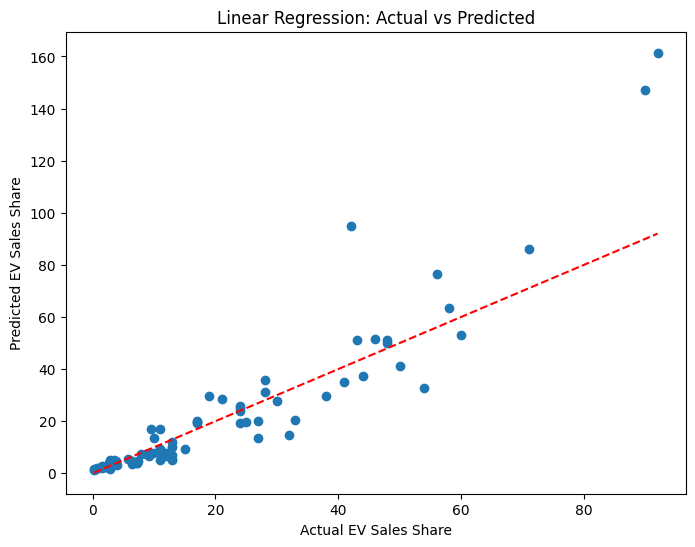

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual EV Sales Share')
plt.ylabel('Predicted EV Sales Share')
plt.title('Linear Regression: Actual vs Predicted')

plt.show()